In [1]:
import pennylane as qml
from executor import Executor, QuantumCircuit, QuantumOperator, Parameters

In [2]:
x = Parameters("x", 1)
p = Parameters("p", 2)

qc = QuantumCircuit(2)
qc.h(0)
qc.cry(0, 1, p[0] * x[0])

In [3]:
pop = Parameters("pop", 2)
operator = QuantumOperator(["ZI", "IZ"], [pop[0], pop[1]])

(<Figure size 700x300 with 1 Axes>, <Axes: >)

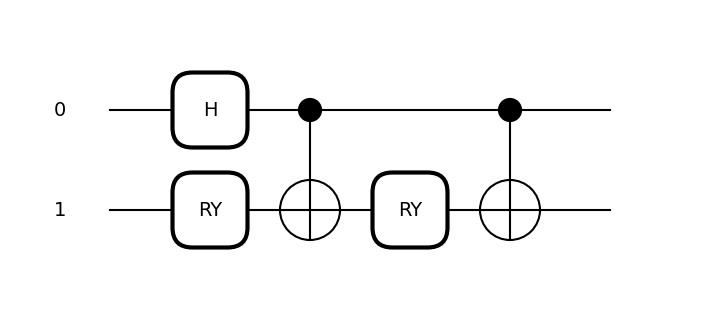

In [4]:
executor = Executor.create("pennylane", seed=0, shots=10000)

pennylane_circuit = executor.transpile_circuit(qc)
qml.draw_mpl(
    qml.QNode(pennylane_circuit.build_pennylane_circuit(), qml.device("default.qubit", wires=2))
)([1.0], [0.5])

In [5]:
result = executor.expectation_value(
    pennylane_circuit,
    operator,
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print("Expectation value:", result)

Expectation value: 0.49988750843724705


In [6]:
v = executor.expectation_value_derivatives(
    pennylane_circuit,
    operator,
    "x",
    "p",
    "pop",
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print(v)

{'p': array([-0.00074989]), 'pop': array([9.99775017e-01, 1.11022302e-16]), 'x': array([-0.00224966])}


c:\Users\mow\Documents\dev\Executor\.venv\Lib\site-packages\pennylane\_grad\grad.py:628: PennyLaneDeprecationWarning: argnum in qml.jacobian has been renamed to argnums to match jax and catalyst.
  warnings.warn(


In [7]:
executor.statevector(
    pennylane_circuit,
    x=[0.8],
    p=[0.5],
)

array([7.07106781e-01+0.j, 6.93011723e-01+0.j, 1.38777878e-17+0.j,
       1.40480431e-01+0.j])

In [8]:
executor.sample(
    pennylane_circuit,
    x=[0.8],
    p=[0.5],
)

c:\Users\mow\Documents\dev\Executor\.venv\Lib\site-packages\pennylane\devices\device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


[{'01': 4815, '00': 4990, '11': 195}]